# Human activity recognition (HAR) evaluation

This notebook downloads public wrist-accelerometry HAR datasets, extracts frozen representations, and evaluates them with a participant-grouped scikit-learn linear probe. 

Install the package first with `pip install -e .` from the repository root. 

The downloads are large, so set `WORK_DIR` to a location with enough space.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import cohen_kappa_score, f1_score
from sklearn.model_selection import GridSearchCV, GroupKFold, LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

from scripts.tutorial_har.extract_har_features import extract_embeddings
from scripts.tutorial_har.plot_umap import compute_umap_table, plot_umap_table
from scripts.tutorial_har.prepare_all_datasets import prepare_datasets

# Datasets and embeddings are written here, relative to the kernel's working
# directory. Point it at a disk with room for the raw downloads.
WORK_DIR = Path('.')

## Download and preprocess the datasets

Each dataset is fetched from its official location and cut into overlapping 60-second windows with a 30-second step, giving one `X.npy`, `Y.npy` and `pid.npy` per dataset. Existing downloads and prepared arrays are reused.

In [2]:
DATASETS = ('PAMAP2', 'RealWorld', 'WISDM')  # include 'Capture24' if you want

dataset_paths = prepare_datasets(WORK_DIR, datasets=DATASETS, epoch_len=60, overlap=30)
dataset_paths

## Extract representations

Each method writes one `[windows, features]` array per dataset to `OUTPUT_ROOT/<method>/<dataset>.npy`, replacing any existing file, and uses a GPU when one is available.

`METHODS` defaults to `sensori` alone, which runs in this environment as installed. The comparison methods depend on software stacks that are hard to harmonize in one environment, so if you add any, their dependency errors surface as they are: install what is missing and rerun that method. Each `extract_<method>` docstring in `extract_har_features.py` lists its requirements.

In [3]:
OUTPUT_ROOT = WORK_DIR / 'embeddings'
METHODS = ('sensori',)  # sensori, handcrafted, moment, biopm, chronos2, harnet30

embedding_paths = {
    method: extract_embeddings(method, dataset_paths, OUTPUT_ROOT, batch_size=256)
    for method in METHODS
}

## Participant-grouped linear probe

Every split is grouped by participant, so windows from one participant never cross a split boundary. The penalty is chosen by [nested cross-validation](https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html): an inner grid search over `C_GRID` scored by macro-F1, then evaluation on participants the search never saw.

In [4]:
N_SPLITS = 5
SEED = 111
C_GRID = [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0, 1000.0, 10000.0]
SCALED_METHODS = {'handcrafted', 'biopm'}


def evaluate_embeddings(embeddings, labels, participants, *, scale_features):
    n_participants = len(np.unique(participants))
    outer_cv = (
        GroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
        if n_participants >= N_SPLITS
        else LeaveOneGroupOut()
    )

    rows = []
    for fold, (train_index, test_index) in enumerate(
        outer_cv.split(embeddings, labels, groups=participants), start=1
    ):
        train_groups = participants[train_index]
        inner_splits = min(N_SPLITS, len(np.unique(train_groups)))
        pipeline = Pipeline(
            [
                ('scaler', StandardScaler() if scale_features else 'passthrough'),
                ('classifier', LogisticRegression(max_iter=10_000, class_weight='balanced')),
            ]
        )
        search = GridSearchCV(
            pipeline,
            param_grid={'classifier__C': C_GRID},
            scoring='f1_macro',
            cv=GroupKFold(n_splits=inner_splits, shuffle=True, random_state=SEED),
            n_jobs=-1,
            error_score='raise',
        )
        search.fit(embeddings[train_index], labels[train_index], groups=train_groups)
        predictions = search.predict(embeddings[test_index])
        rows.append(
            {
                'fold': fold,
                'C': search.best_params_['classifier__C'],
                'F1_macro': f1_score(labels[test_index], predictions, average='macro'),
                'kappa': cohen_kappa_score(labels[test_index], predictions),
            }
        )
    return pd.DataFrame(rows)

In [5]:
fold_tables = []
for method in METHODS:
    for dataset_name in DATASETS:
        print(f'Processing {method}/{dataset_name}...')
        data_path = dataset_paths[dataset_name]
        embeddings = np.load(embedding_paths[method][dataset_name])
        labels = LabelEncoder().fit_transform(np.load(data_path / 'Y.npy', allow_pickle=True))
        participants = np.load(data_path / 'pid.npy', allow_pickle=True)

        fold_table = evaluate_embeddings(
            embeddings, labels, participants, scale_features=method in SCALED_METHODS
        )
        fold_table.insert(0, 'dataset', dataset_name)
        fold_table.insert(0, 'method', method)
        fold_tables.append(fold_table)

Processing sensori/PAMAP2...


Processing sensori/RealWorld...
Processing sensori/WISDM...


## Summary

The table reports the mean and standard deviation across outer participant-grouped folds. `selected_C` records the penalty chosen independently in each fold.

Small differences from the numbers reported in the paper are expected: hardware and library versions shift the embeddings slightly, which can change the penalty a fold selects. They stay well inside the fold-to-fold standard deviation.

In [6]:
fold_results = pd.concat(fold_tables, ignore_index=True)
summary = (
    fold_results.groupby(['method', 'dataset'], sort=False)
    .agg(
        n_folds=('fold', 'count'),
        F1_macro_mean=('F1_macro', 'mean'),
        F1_macro_std=('F1_macro', 'std'),
        kappa_mean=('kappa', 'mean'),
        kappa_std=('kappa', 'std'),
        selected_C=(
            'C',
            lambda values: (
                f'{values.iloc[0]:g}' if values.nunique() == 1 else ';'.join(f'{value:g}' for value in values)
            ),
        ),
    )
    .reset_index()
    .round(6)
)

summary

,method,dataset,n_folds,F1_macro_mean,F1_macro_std,kappa_mean,kappa_std,selected_C
0,sensori,PAMAP2,5,0.847581,0.070650,0.842287,0.071275,10;100;100;0.1;0.1
1,sensori,RealWorld,5,0.863026,0.022680,0.826459,0.030965,0.1;0.1;0.1;0.1;1
2,sensori,WISDM,5,0.815066,0.079801,0.805389,0.083377,0.1


## UMAP visualization

UMAP projections of the Sensori 1-minute embeddings, coloured by the labelled activity.

PAMAP2: fitting UMAP on 486 samples
RealWorld: fitting UMAP on 2,019 samples
WISDM: fitting UMAP on 3,682 samples


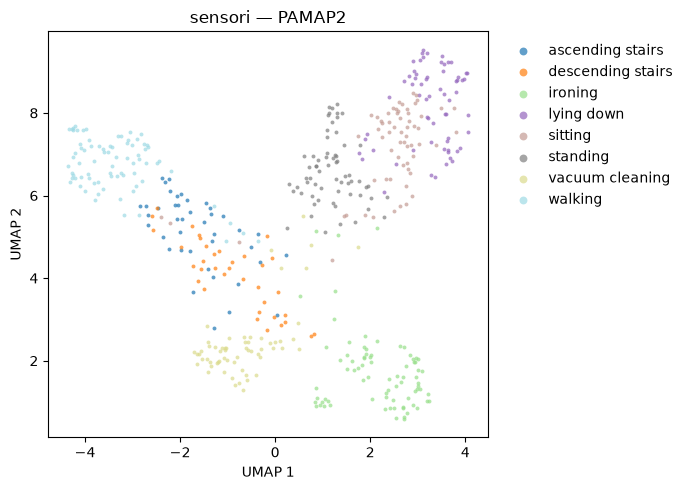

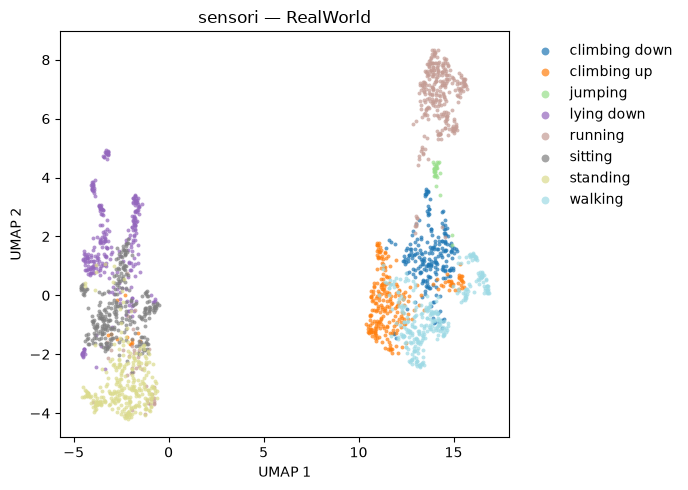

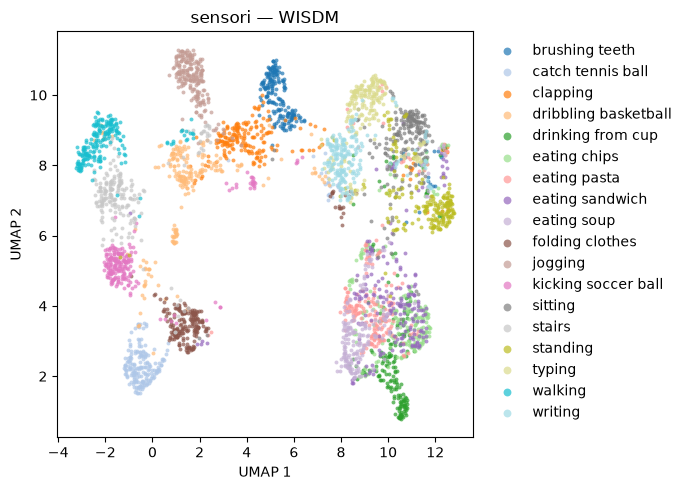

In [7]:
UMAP_METHOD = 'sensori'

umap_tables = {}
for dataset_name in DATASETS:
    umap_tables[dataset_name] = compute_umap_table(dataset_name, WORK_DIR, OUTPUT_ROOT / UMAP_METHOD)
    plot_umap_table(umap_tables[dataset_name], title=f'{UMAP_METHOD} — {dataset_name}')

plt.show()